In [1]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from os.path import exists

sys.path.append('../..')

In [3]:
import pylab as plt
import pandas as pd
import numpy as np
from loguru import logger
import seaborn as sns

from stable_baselines3 import PPO, DQN

In [4]:
from vimms.Common import POSITIVE, set_log_level_warning, load_obj, save_obj
from vimms.ChemicalSamplers import UniformRTAndIntensitySampler, GaussianChromatogramSampler, UniformMZFormulaSampler, \
    MZMLFormulaSampler, MZMLRTandIntensitySampler, MZMLChromatogramSampler
from vimms.Noise import UniformSpikeNoise
from vimms.Evaluation import evaluate_real
from vimms.Chemicals import ChemicalMixtureFromMZML
from vimms.Roi import RoiBuilderParams, SmartRoiParams

from mass_spec_utils.data_import.mzmine import load_picked_boxes

from vimms_gym.env import DDAEnv
from vimms_gym.chemicals import generate_chemicals
from vimms_gym.evaluation import evaluate, run_method
from vimms_gym.common import METHOD_RANDOM, METHOD_FULLSCAN, METHOD_TOPN, METHOD_PPO, METHOD_DQN

# 1. Parameters

In [5]:
# n_chemicals = (200, 500)
# mz_range = (100, 600)
# rt_range = (0, 300)
# intensity_range = (1E5, 1E10)

In [6]:
n_chemicals = (20, 50)
mz_range = (100, 110)
rt_range = (400, 500)
intensity_range = (1E4, 1E20)

In [7]:
min_mz = mz_range[0]
max_mz = mz_range[1]
min_rt = rt_range[0]
max_rt = rt_range[1]
min_log_intensity = np.log(intensity_range[0])
max_log_intensity = np.log(intensity_range[1])

In [8]:
isolation_window = 0.7
N = 10
rt_tol = 120
exclusion_t_0 = 15
mz_tol = 10
min_ms1_intensity = 5000
ionisation_mode = POSITIVE

enable_spike_noise = True
noise_density = 0.1
noise_max_val = 1E3

In [9]:
mz_sampler = UniformMZFormulaSampler(min_mz=min_mz, max_mz=max_mz)
ri_sampler = UniformRTAndIntensitySampler(min_rt=min_rt, max_rt=max_rt,
                                          min_log_intensity=min_log_intensity,
                                          max_log_intensity=max_log_intensity)
cr_sampler = GaussianChromatogramSampler()
samplers = {
    'mz': mz_sampler,
    'rt_intensity': ri_sampler,
    'chromatogram': cr_sampler
}

In [10]:
params = {
    'chemical_creator': {
        'mz_range': mz_range,
        'rt_range': rt_range,
        'intensity_range': intensity_range,
        'n_chemicals': n_chemicals,
        'mz_sampler': mz_sampler,
        'ri_sampler': ri_sampler,
        'cr_sampler': cr_sampler,
    },
    'noise': {
        'enable_spike_noise': enable_spike_noise,
        'noise_density': noise_density,
        'noise_max_val': noise_max_val,
        'mz_range': mz_range
    },
    'env': {
        'ionisation_mode': ionisation_mode,
        'rt_range': rt_range,
        'isolation_window': isolation_window,
        'mz_tol': mz_tol,
        'rt_tol': rt_tol,
    }
}

In [11]:
max_peaks = 100
in_dir = 'results'

In [12]:
n_eval_episodes = 30
deterministic = True

# 2. Evaluation

#### Generate some chemical sets

In [13]:
set_log_level_warning()

1

In [14]:
eval_dir = 'evaluation'
methods = [
    METHOD_RANDOM,    
    METHOD_PPO,
    METHOD_DQN,
    METHOD_TOPN,
]

In [15]:
chemical_creator_params = params['chemical_creator']

chem_list = []
for i in range(n_eval_episodes):
    print(i)
    chems = generate_chemicals(chemical_creator_params)
    chem_list.append(chems)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29


#### Run different methods

In [16]:
for chems in chem_list:
    print(len(chems))

37
35
49
41
32
20
39
22
36
42
36
35
24
43
48
36
23
30
42
43
24
47
37
27
36
31
25
40
38
32


In [17]:
max_peaks

100

In [18]:
out_dir = eval_dir
in_dir, out_dir

('results', 'evaluation')

#### Compare to Top-10

In [19]:
env_name = 'DDAEnv'
intensity_threshold = 0.5

In [20]:
topN_N = 10
topN_rt_tol = 5

In [21]:
method_eval_results = {}
for method in methods:

    effective_rt_tol = rt_tol
    copy_params = dict(params)        
    copy_params['env']['rt_tol'] = effective_rt_tol
    
    if method == METHOD_PPO:
        fname = os.path.join(in_dir, '%s_%s.zip' % (env_name, method))
        model = PPO.load(fname)
    elif method == METHOD_DQN:
        fname = os.path.join(in_dir, '%s_%s.zip' % (env_name, method))
        model = DQN.load(fname)
    else:
        model = None
        if method == METHOD_TOPN:
            N = topN_N
            effective_rt_tol = topN_rt_tol
            copy_params = dict(params)        
            copy_params['env']['rt_tol'] = effective_rt_tol                        

    banner = 'method = %s max_peaks = %d N = %d rt_tol = %d' % (method, max_peaks, N, effective_rt_tol)
    print(banner)
    print()            
            
    episodic_results = run_method(env_name, copy_params, max_peaks, chem_list, method, out_dir, 
                                  N=N, min_ms1_intensity=min_ms1_intensity, model=model,
                                  print_eval=True, print_reward=False, intensity_threshold=intensity_threshold)
    eval_results = [er.eval_res for er in episodic_results]
    method_eval_results[method] = eval_results
    print()

method = random max_peaks = 100 N = 10 rt_tol = 120

{'coverage_prop': '0.730', 'intensity_prop': '0.578', 'ms1/ms2 ratio': '0.012', 'efficiency': '0.055', 'TP': '14', 'FP': '5', 'FN': '18', 'precision': '0.737', 'recall': '0.438', 'f1': '0.549'}
{'coverage_prop': '0.714', 'intensity_prop': '0.527', 'ms1/ms2 ratio': '0.019', 'efficiency': '0.052', 'TP': '9', 'FP': '4', 'FN': '22', 'precision': '0.692', 'recall': '0.290', 'f1': '0.409'}
{'coverage_prop': '0.000', 'intensity_prop': '0.000', 'ms1/ms2 ratio': '0.002', 'efficiency': '0.000', 'TP': '0', 'FP': '0', 'FN': '49', 'precision': '0.000', 'recall': '0.000', 'f1': '0.000'}
{'coverage_prop': '0.878', 'intensity_prop': '0.685', 'ms1/ms2 ratio': '0.019', 'efficiency': '0.075', 'TP': '18', 'FP': '6', 'FN': '17', 'precision': '0.750', 'recall': '0.514', 'f1': '0.610'}
{'coverage_prop': '0.750', 'intensity_prop': '0.487', 'ms1/ms2 ratio': '0.012', 'efficiency': '0.049', 'TP': '9', 'FP': '8', 'FN': '15', 'precision': '0.529', 'recall': '0.3

#### Test classic controllers in ViMMS

In [22]:
from vimms.MassSpec import IndependentMassSpectrometer
from vimms.Controller import TopNController, TopN_SmartRoiController, WeightedDEWController
from vimms.Environment import Environment

Run Top-N Controller

In [23]:
method = 'TopN_Controller'
print('method = %s' % method)
print()

effective_rt_tol = topN_rt_tol
effective_N = topN_N
eval_results = []
for i in range(len(chem_list)):
    
    spike_noise = None
    if enable_spike_noise:
        noise_params = params['noise']
        noise_density = noise_params['noise_density']
        noise_max_val = noise_params['noise_max_val']
        noise_min_mz = noise_params['mz_range'][0]
        noise_max_mz = noise_params['mz_range'][1]
        spike_noise = UniformSpikeNoise(noise_density, noise_max_val, min_mz=noise_min_mz,
                                        max_mz=noise_max_mz)

    chems = chem_list[i]
    mass_spec = IndependentMassSpectrometer(ionisation_mode, chems, spike_noise=spike_noise)
    controller = TopNController(ionisation_mode, effective_N, isolation_window, mz_tol, effective_rt_tol,
                                min_ms1_intensity)
    env = Environment(mass_spec, controller, min_rt, max_rt, progress_bar=False, out_dir=out_dir,
                      out_file='%s_%d.mzML' % (method, i), save_eval=True)
    env.run()
    
    eval_res = evaluate(env, intensity_threshold)
    eval_results.append(eval_res)
    print('Episode %d finished' % i)
    print(eval_res)
    
method_eval_results[method] = eval_results

method = TopN_Controller

Episode 0 finished
{'coverage_prop': '0.973', 'intensity_prop': '0.783', 'ms1/ms2 ratio': '0.475', 'efficiency': '0.140', 'TP': '21', 'FP': '6', 'FN': '10', 'precision': '0.778', 'recall': '0.677', 'f1': '0.724'}
Episode 1 finished
{'coverage_prop': '0.971', 'intensity_prop': '0.850', 'ms1/ms2 ratio': '0.531', 'efficiency': '0.140', 'TP': '19', 'FP': '11', 'FN': '5', 'precision': '0.633', 'recall': '0.792', 'f1': '0.704'}
Episode 2 finished
{'coverage_prop': '0.980', 'intensity_prop': '0.941', 'ms1/ms2 ratio': '0.290', 'efficiency': '0.151', 'TP': '25', 'FP': '9', 'FN': '15', 'precision': '0.735', 'recall': '0.625', 'f1': '0.676'}
Episode 3 finished
{'coverage_prop': '1.000', 'intensity_prop': '0.864', 'ms1/ms2 ratio': '0.355', 'efficiency': '0.140', 'TP': '23', 'FP': '9', 'FN': '9', 'precision': '0.719', 'recall': '0.719', 'f1': '0.719'}
Episode 4 finished
{'coverage_prop': '0.938', 'intensity_prop': '0.921', 'ms1/ms2 ratio': '0.522', 'efficiency': '0.122', '

Run SmartROI Controller

In [24]:
alpha = 2
beta = 0.1
smartroi_N = 10
smartroi_dew = 5

In [25]:
method = 'SmartROI_Controller'
print('method = %s' % method)
print()

effective_rt_tol = exclusion_t_0
eval_results = []
for i in range(len(chem_list)):
    
    spike_noise = None
    if enable_spike_noise:
        noise_params = params['noise']
        noise_density = noise_params['noise_density']
        noise_max_val = noise_params['noise_max_val']
        noise_min_mz = noise_params['mz_range'][0]
        noise_max_mz = noise_params['mz_range'][1]
        spike_noise = UniformSpikeNoise(noise_density, noise_max_val, min_mz=noise_min_mz,
                                        max_mz=noise_max_mz)

    chems = chem_list[i]
    mass_spec = IndependentMassSpectrometer(ionisation_mode, chems, spike_noise=spike_noise)
    
    roi_params = RoiBuilderParams(min_roi_intensity=500, min_roi_length=0)    
    smartroi_params = SmartRoiParams(intensity_increase_factor=alpha, drop_perc=beta/100.0)
    controller = TopN_SmartRoiController(ionisation_mode, isolation_window, smartroi_N, mz_tol, smartroi_dew,
                                min_ms1_intensity, roi_params, smartroi_params)
    env = Environment(mass_spec, controller, min_rt, max_rt, progress_bar=False, out_dir=out_dir,
                      out_file='%s_%d.mzML' % (method, i), save_eval=True)
    env.run()
    
    eval_res = evaluate(env, intensity_threshold)
    eval_results.append(eval_res)
    print('Episode %d finished' % i)
    print(eval_res)
    
method_eval_results[method] = eval_results

method = SmartROI_Controller

Episode 0 finished
{'coverage_prop': '0.919', 'intensity_prop': '0.711', 'ms1/ms2 ratio': '3.683', 'efficiency': '0.567', 'TP': '19', 'FP': '4', 'FN': '14', 'precision': '0.826', 'recall': '0.576', 'f1': '0.679'}
Episode 1 finished
{'coverage_prop': '0.886', 'intensity_prop': '0.760', 'ms1/ms2 ratio': '3.746', 'efficiency': '0.525', 'TP': '17', 'FP': '7', 'FN': '11', 'precision': '0.708', 'recall': '0.607', 'f1': '0.654'}
Episode 2 finished
{'coverage_prop': '0.980', 'intensity_prop': '0.887', 'ms1/ms2 ratio': '2.194', 'efficiency': '0.516', 'TP': '19', 'FP': '8', 'FN': '22', 'precision': '0.704', 'recall': '0.463', 'f1': '0.559'}
Episode 3 finished
{'coverage_prop': '0.976', 'intensity_prop': '0.814', 'ms1/ms2 ratio': '2.892', 'efficiency': '0.541', 'TP': '21', 'FP': '7', 'FN': '13', 'precision': '0.750', 'recall': '0.618', 'f1': '0.677'}
Episode 4 finished
{'coverage_prop': '0.938', 'intensity_prop': '0.867', 'ms1/ms2 ratio': '3.746', 'efficiency': '0.50

Run WeightedDEW Controller

In [26]:
t0 = 5
t1 = 15
weighteddew_N = 10

In [27]:
method = 'WeightedDEW_Controller'
print('method = %s' % method)
print()

eval_results = []
for i in range(len(chem_list)):
    
    spike_noise = None
    if enable_spike_noise:
        noise_params = params['noise']
        noise_density = noise_params['noise_density']
        noise_max_val = noise_params['noise_max_val']
        noise_min_mz = noise_params['mz_range'][0]
        noise_max_mz = noise_params['mz_range'][1]
        spike_noise = UniformSpikeNoise(noise_density, noise_max_val, min_mz=noise_min_mz,
                                        max_mz=noise_max_mz)

    chems = chem_list[i]
    mass_spec = IndependentMassSpectrometer(ionisation_mode, chems, spike_noise=spike_noise)
    
    controller = WeightedDEWController(ionisation_mode, weighteddew_N, isolation_window, mz_tol, t1,
                                min_ms1_intensity, exclusion_t_0=t0)
    env = Environment(mass_spec, controller, min_rt, max_rt, progress_bar=False, out_dir=out_dir,
                      out_file='%s_%d.mzML' % (method, i), save_eval=True)
    env.run()
    
    eval_res = evaluate(env, intensity_threshold)
    eval_results.append(eval_res)
    print('Episode %d finished' % i)
    print(eval_res)
    
method_eval_results[method] = eval_results

method = WeightedDEW_Controller

Episode 0 finished
{'coverage_prop': '0.973', 'intensity_prop': '0.783', 'ms1/ms2 ratio': '0.475', 'efficiency': '0.140', 'TP': '21', 'FP': '6', 'FN': '10', 'precision': '0.778', 'recall': '0.677', 'f1': '0.724'}
Episode 1 finished
{'coverage_prop': '0.971', 'intensity_prop': '0.849', 'ms1/ms2 ratio': '0.531', 'efficiency': '0.140', 'TP': '19', 'FP': '11', 'FN': '5', 'precision': '0.633', 'recall': '0.792', 'f1': '0.704'}
Episode 2 finished
{'coverage_prop': '0.980', 'intensity_prop': '0.942', 'ms1/ms2 ratio': '0.290', 'efficiency': '0.151', 'TP': '25', 'FP': '9', 'FN': '15', 'precision': '0.735', 'recall': '0.625', 'f1': '0.676'}
Episode 3 finished
{'coverage_prop': '1.000', 'intensity_prop': '0.864', 'ms1/ms2 ratio': '0.355', 'efficiency': '0.140', 'TP': '23', 'FP': '9', 'FN': '9', 'precision': '0.719', 'recall': '0.719', 'f1': '0.719'}
Episode 4 finished
{'coverage_prop': '0.938', 'intensity_prop': '0.922', 'ms1/ms2 ratio': '0.522', 'efficiency': '0.

#### Plotting

Flatten data into dataframe

In [28]:
data = []
for method in method_eval_results:
    eval_results = method_eval_results[method]
    for eval_res in eval_results:
        row = (
            method, 
            float(eval_res['coverage_prop']), 
            float(eval_res['intensity_prop']), 
            float(eval_res['ms1/ms2 ratio']), 
            float(eval_res['efficiency']),
            float(eval_res['precision']),
            float(eval_res['recall']),
            float(eval_res['f1']),            
        )
        data.append(row)
        
df = pd.DataFrame(data, columns=['method', 'coverage_prop', 'intensity_prop', 'ms1/ms2_ratio', 'efficiency', 'precision', 'recall', 'f1'])
# df.set_index('method', inplace=True)
df.head()

,method,coverage_prop,intensity_prop,ms1/ms2_ratio,efficiency,precision,recall,f1
0,random,0.730,0.578,0.012,0.055,0.737,0.438,0.549
1,random,0.714,0.527,0.019,0.052,0.692,0.290,0.409
2,random,0.000,0.000,0.002,0.000,0.000,0.000,0.000
3,random,0.878,0.685,0.019,0.075,0.750,0.514,0.610
4,random,0.750,0.487,0.012,0.049,0.529,0.375,0.439


In [29]:
sns.set_context("poster")

Text(0.5, 1.0, 'Coverage Proportion')

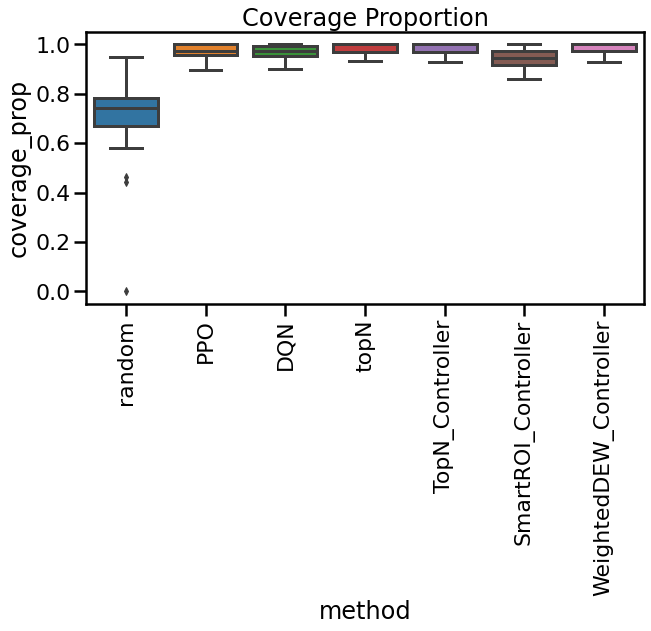

In [30]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='method', y='coverage_prop')
plt.xticks(rotation=90)
plt.title('Coverage Proportion')

Text(0.5, 1.0, 'Intensity Proportion')

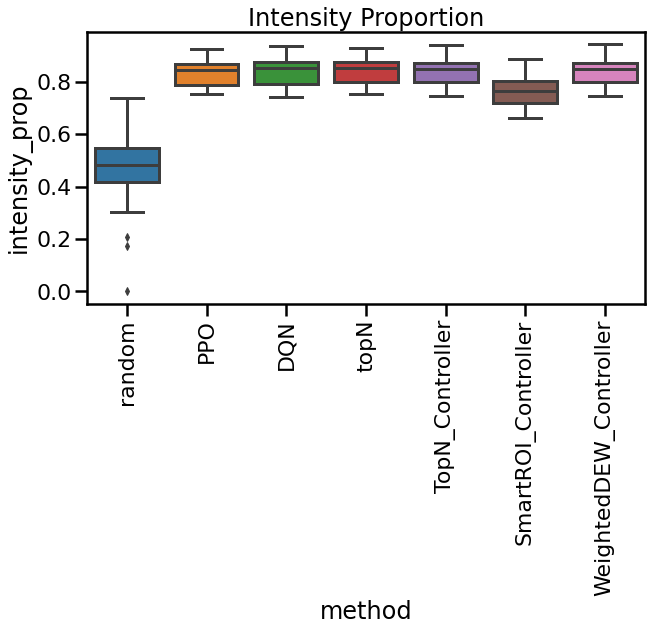

In [31]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='method', y='intensity_prop')
plt.xticks(rotation=90)
plt.title('Intensity Proportion')

Text(0.5, 1.0, 'MS1/MS2 Ratio')

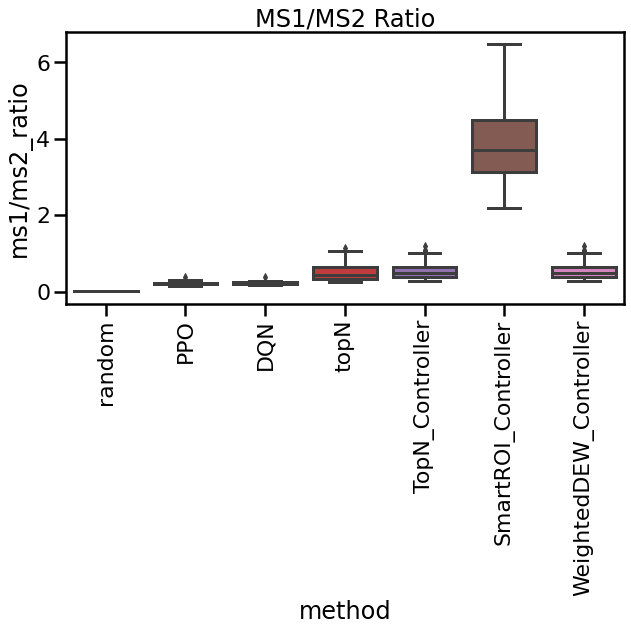

In [32]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='method', y='ms1/ms2_ratio')
plt.xticks(rotation=90)
plt.title('MS1/MS2 Ratio')

Text(0.5, 1.0, 'Efficiency')

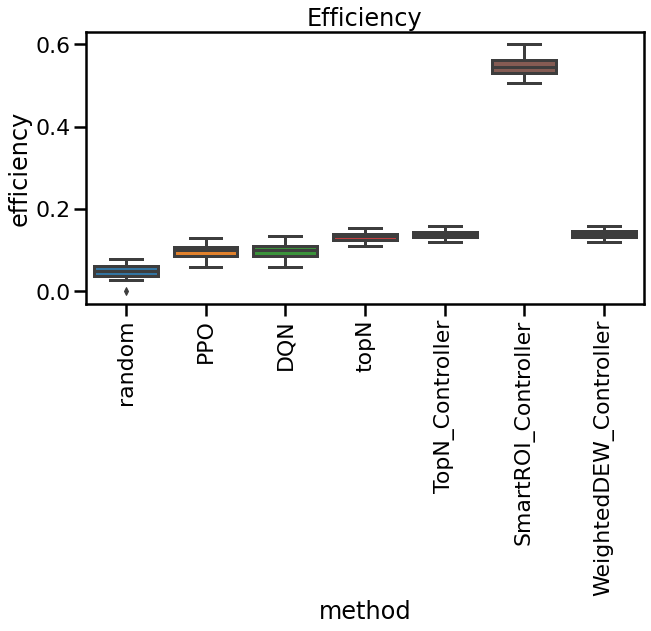

In [33]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='method', y='efficiency')
plt.xticks(rotation=90)
plt.title('Efficiency')

Text(0.5, 1.0, 'Precision')

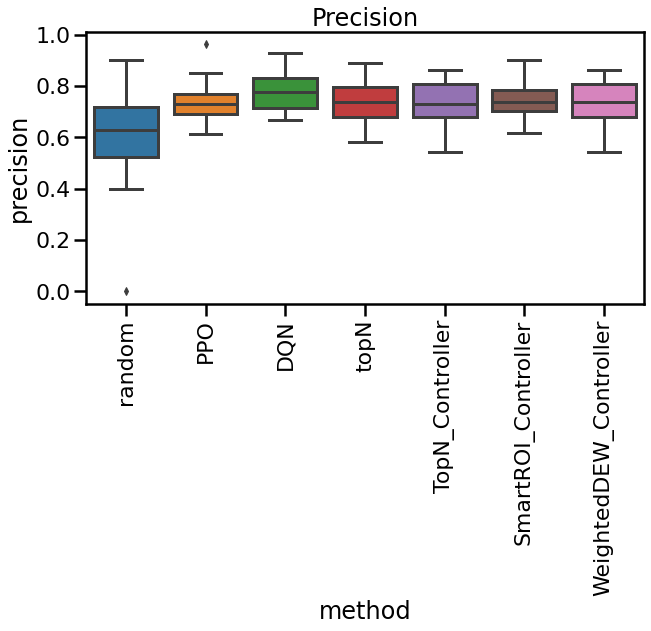

In [34]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='method', y='precision')
plt.xticks(rotation=90)
plt.title('Precision')

Text(0.5, 1.0, 'Recall')

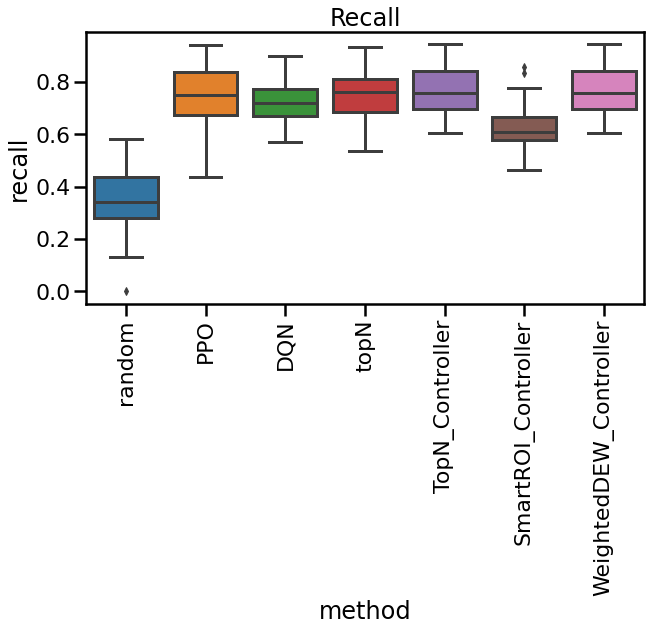

In [35]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='method', y='recall')
plt.xticks(rotation=90)
plt.title('Recall')

Text(0.5, 1.0, 'F1')

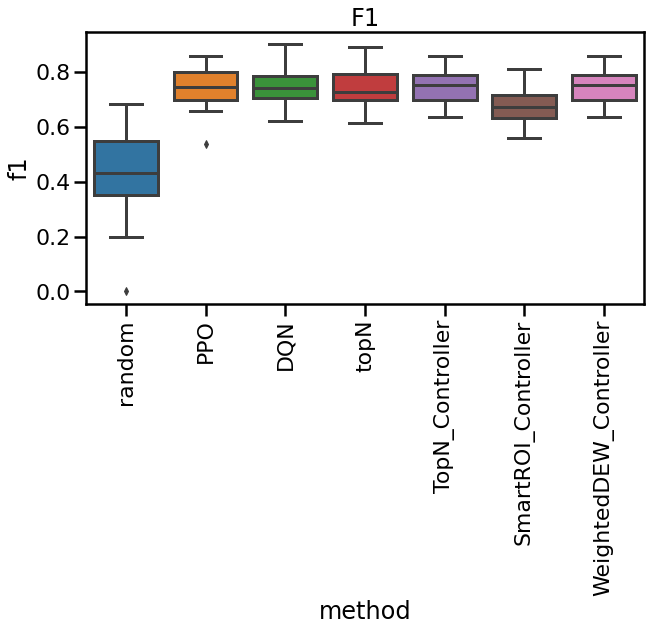

In [36]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='method', y='f1')
plt.xticks(rotation=90)
plt.title('F1')

In [37]:
df.to_pickle('evaluation.p')